In [ ]:
import numpy as np
import torch
from clawpack import pyclaw


def generate_gaussian_random_field_1d(size, mean=0, std=1, smoothness=1):
    """
    Generates a 1D Gaussian random field.

    Args:
        size (int): The number of points in the field.
        mean (float): Mean of the Gaussian distribution.
        std (float): Standard deviation of the Gaussian distribution.
        smoothness (float): Smoothness of the field (standard deviation of the Gaussian kernel).

    Returns:
        numpy.ndarray: A 1D numpy array representing the Gaussian random field.
    """
    # Generate uncorrelated Gaussian noise
    noise = np.random.normal(mean, std, size)

    # Smooth the noise using a Gaussian filter
    smoothed_noise = gaussian_filter(noise, sigma=smoothness)

    return smoothed_noise


def covariance_1(ampl, size):
    coeff = np.zeros(2 * size)

    for i in range(size):
        coeff[i] = np.exp(-i / ampl)

    for i in range(size - 1):
        coeff[2 * size - 1 - i] = np.exp(-(i + 1) / ampl)

    return coeff


def covariance_2(ampl, size):
    coeff = np.zeros(2 * size)

    for i in range(size):
        coeff[i] = np.exp(-(i**2) / ampl**2)

    for i in range(size - 1):
        coeff[2 * size - 1 - i] = np.exp(-((i + 1) ** 2) / ampl**2)

    return coeff


def generator_1D(cov, ampl, size):
    coeff = np.fft.fft(cov(ampl * size, int(size / 2)))

    X = np.zeros((size, size))
    np.fill_diagonal(X, np.sqrt(coeff))

    theta = np.random.normal(size=size) + 1j * np.random.normal(size=size)
    gfield = np.fft.ifft(np.matmul(X, theta)).real[:size]

    return (gfield - np.mean(gfield)) / np.std(gfield)


def riemann_poly(q_l, q_r, aux_l, aux_r, problem_data):
    a, b, c = problem_data["a"], problem_data["b"], problem_data["c"]
    dq = q_r - q_l

    # 안전한 특성 속도 계산 (0/0 경고 방지)
    f_l = a * q_l**3 + b * q_l**2 + c * q_l
    f_r = a * q_r**3 + b * q_r**2 + c * q_r
    s = 3 * a * q_l**2 + 2 * b * q_l + c  # 기본값
    mask = np.abs(dq) > 1.0e-14  # dq가 충분히 크면 직접 계산
    s[mask] = (f_r[mask] - f_l[mask]) / dq[mask]

    # --------- PyClaw가 기대하는 형태로 재배열 ---------
    wave = dq.reshape(1, 1, -1)  # (num_eqn=1, num_waves=1, num_rp)
    s = s.reshape(1, -1)  # (1, num_rp)
    amdq = (np.minimum(s, 0.0) * dq).copy()  # (1, num_rp)
    apdq = (np.maximum(s, 0.0) * dq).copy()  # (1, num_rp)

    return wave, s, amdq, apdq


def step_source(solver, state, dt):
    k = 0  # state.problem_data['k']          # 감쇠율
    state.q[0, :] += dt * (-k * state.q[0, :])


# ---- Solver -----------------------------------------------------------
solver = pyclaw.ClawSolver1D(riemann_poly)
solver.num_eqn = 1  # ★ 직접 지정
solver.num_waves = 1
solver.limiters = pyclaw.limiters.tvd.MC
solver.cfl_desired = 0.5
solver.cfl_max = 0.9
solver.kernel_language = "Python"  # ★ 중요: Python 커널 사용
# ---- Grid & State -----------------------------------------------------
domain = pyclaw.Domain([-1.0], [1.0], [256])
solution = pyclaw.Solution(1, domain)  # ★ 숫자 직접 전달
state = solution.state
solver.fwave = False  # ★ 추가
# 물리 계수
state.problem_data["a"] = 2 * np.random.rand() - 1
state.problem_data["b"] = 2 * np.random.rand() - 1
state.problem_data["c"] = 2 * np.random.rand() - 1
state.problem_data["k"] = np.random.rand()

# 초기 조건
x = state.grid.p_centers[0]
state.q[0, :] = generator_1D(covariance_2, 0.05, 256)


# --- 소스항 관련 옵션 ---
solver.step_source = step_source  # 소스 스텝 함수 등록
solver.source_split = 2  # Strang splitting (½S–H–½S)


# --------------------------------------------------
# 3. BC & Run
# --------------------------------------------------
solver.bc_lower[0] = pyclaw.BC.periodic
solver.bc_upper[0] = pyclaw.BC.periodic

controller = pyclaw.Controller()
controller.num_output_times = 100
controller.solver = solver
controller.solution = solution
controller.tfinal = 0.1

# status = controller.run()
# print(status)

/home/taeyoungkim/anaconda3/envs/py311/lib/python3.11/site-packages/numpy/lib/index_tricks.py:916: ComplexWarning: Casting complex values to real discards the imaginary part
  a.flat[:end:step] = val


In [ ]:
# N : NUMBER OF FUNCTIONS, M : DOMAIN SIZE, T : TIME GRID SIZE
# controller.tfinal : FINAL TIME


def generator(N, M, T):
    qqq = torch.zeros([N, M, T, 2])
    for j in range(N):
        # ---- Solver -----------------------------------------------------------
        solver = pyclaw.ClawSolver1D(riemann_poly)
        solver.num_eqn = 1  # ★ 직접 지정
        solver.num_waves = 1
        solver.limiters = pyclaw.limiters.tvd.MC
        solver.cfl_desired = 0.5
        solver.cfl_max = 0.9
        solver.kernel_language = "Python"  # ★ 중요: Python 커널 사용
        # ---- Grid & State -----------------------------------------------------
        domain = pyclaw.Domain([-1.0], [1.0], [256])
        solution = pyclaw.Solution(1, domain)  # ★ 숫자 직접 전달
        state = solution.state
        solver.fwave = False  # ★ 추가
        # 물리 계수
        state.problem_data["a"] = 0.1 * np.random.rand()
        state.problem_data["b"] = 0.1 * np.random.rand()
        state.problem_data["c"] = 0.1 * np.random.rand()
        state.problem_data["k"] = np.random.rand()

        # 초기 조건
        x = state.grid.p_centers[0]
        state.q[0, :] = generator_1D(covariance_2, 0.05, M)

        # --- 소스항 관련 옵션 ---
        solver.step_source = step_source  # 소스 스텝 함수 등록
        solver.source_split = 2  # Strang splitting (½S–H–½S)

        # --------------------------------------------------
        # 3. BC & Run
        # --------------------------------------------------
        solver.bc_lower[0] = pyclaw.BC.periodic
        solver.bc_upper[0] = pyclaw.BC.periodic

        controller = pyclaw.Controller()
        controller.num_output_times = T
        controller.solver = solver
        controller.solution = solution
        controller.tfinal = 0.02

        status = controller.run()
        # print(status)
        q0 = pyclaw.Solution(0).q[0]
        qq = torch.tensor(q0).unsqueeze(-1).unsqueeze(-1)
        qq = torch.cat(
            (
                qq,
                (
                    state.problem_data["a"] * qq**3
                    + state.problem_data["b"] * qq**2
                    + state.problem_data["c"] * qq
                ),
            ),
            dim=2,
        )
        print(qq.shape)
        for i in range(1, T):
            q0 = pyclaw.Solution(i).q[0]
            q1 = torch.tensor(q0).unsqueeze(-1).unsqueeze(-1)
            q1 = torch.cat(
                (
                    q1,
                    (
                        state.problem_data["a"] * q1**3
                        + state.problem_data["b"] * q1**2
                        + state.problem_data["c"] * q1
                    ),
                ),
                dim=2,
            )
            qq = torch.cat((qq, q1), dim=1)

        qq.unsqueeze(0)
        qqq[j] = qq

    return qqq

In [ ]:
aaa = generator(5, 256, 100)

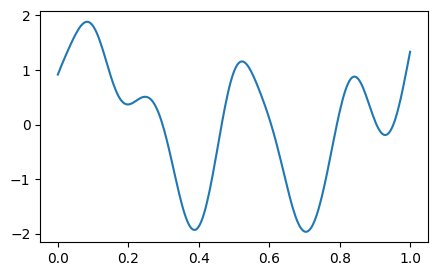

In [ ]:
import pickle


with open(file="testdataset_no_source_01_10_100.pickle", mode="wb") as f:
    pickle.dump(aaa, f)

In [ ]:
## 정리된 예시


def covariance_1(ampl, size):
    coeff = np.zeros(2 * size)

    for i in range(size):
        coeff[i] = np.exp(-i / ampl)

    for i in range(size - 1):
        coeff[2 * size - 1 - i] = np.exp(-(i + 1) / ampl)

    return coeff


def covariance_2(ampl, size):
    coeff = np.zeros(2 * size)

    for i in range(size):
        coeff[i] = np.exp(-(i**2) / ampl**2)

    for i in range(size - 1):
        coeff[2 * size - 1 - i] = np.exp(-((i + 1) ** 2) / ampl**2)

    return coeff


def generator_1D(cov, ampl, size):
    coeff = np.fft.fft(cov(ampl * size, int(size / 2)))

    X = np.zeros((size, size))
    np.fill_diagonal(X, np.sqrt(coeff))

    theta = np.random.normal(size=size) + 1j * np.random.normal(size=size)
    gfield = np.fft.ifft(np.matmul(X, theta)).real[:size]

    return (gfield - np.mean(gfield)) / np.std(gfield)


def riemann_poly(q_l, q_r, aux_l, aux_r, problem_data):
    a, b, c = problem_data["a"], problem_data["b"], problem_data["c"]
    dq = q_r - q_l

    # 안전한 특성 속도 계산 (0/0 경고 방지)
    f_l = a * q_l**3 + b * q_l**2 + c * q_l
    f_r = a * q_r**3 + b * q_r**2 + c * q_r
    s = 3 * a * q_l**2 + 2 * b * q_l + c  # 기본값
    mask = np.abs(dq) > 1.0e-14  # dq가 충분히 크면 직접 계산
    s[mask] = (f_r[mask] - f_l[mask]) / dq[mask]

    # --------- PyClaw가 기대하는 형태로 재배열 ---------
    wave = dq.reshape(1, 1, -1)  # (num_eqn=1, num_waves=1, num_rp)
    s = s.reshape(1, -1)  # (1, num_rp)
    amdq = (np.minimum(s, 0.0) * dq).copy()  # (1, num_rp)
    apdq = (np.maximum(s, 0.0) * dq).copy()  # (1, num_rp)

    return wave, s, amdq, apdq


def step_source(solver, state, dt):
    k = 0  # state.problem_data['k']          # 감쇠율
    state.q[0, :] += dt * (-k * state.q[0, :])


# ---- Solver -----------------------------------------------------------
solver = pyclaw.ClawSolver1D(riemann_poly)
solver.num_eqn = 1  # ★ 직접 지정
solver.num_waves = 1
solver.limiters = pyclaw.limiters.tvd.MC
solver.cfl_desired = 0.5
solver.cfl_max = 0.9
solver.kernel_language = "Python"  # ★ 중요: Python 커널 사용
# ---- Grid & State -----------------------------------------------------
domain = pyclaw.Domain([-1.0], [1.0], [256])
solution = pyclaw.Solution(1, domain)  # ★ 숫자 직접 전달
state = solution.state
solver.fwave = False  # ★ 추가
# 물리 계수
state.problem_data["a"] = 2 * np.random.rand() - 1
state.problem_data["b"] = 2 * np.random.rand() - 1
state.problem_data["c"] = 2 * np.random.rand() - 1
state.problem_data["k"] = np.random.rand()

# 초기 조건
x = state.grid.p_centers[0]
state.q[0, :] = generator_1D(covariance_2, 0.05, 256)


# --- 소스항 관련 옵션 ---
solver.step_source = step_source  # 소스 스텝 함수 등록
solver.source_split = 2  # Strang splitting (½S–H–½S)


# --------------------------------------------------
# 3. BC & Run
# --------------------------------------------------
solver.bc_lower[0] = pyclaw.BC.periodic
solver.bc_upper[0] = pyclaw.BC.periodic

controller = pyclaw.Controller()
controller.num_output_times = 100
controller.solver = solver
controller.solution = solution
controller.tfinal = 0.1

# status = controller.run()
# print(status)

/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/numpy/lib/_index_tricks_impl.py:942: ComplexWarning: Casting complex values to real discards the imaginary part
  a.flat[:end:step] = val


In [ ]:
# N : NUMBER OF FUNCTIONS, M : DOMAIN SIZE, T : TIME GRID SIZE
# controller.tfinal : FINAL TIME


def generator(N, M, T):
    qqq = torch.zeros([N, M, T, 2])
    for j in range(N):
        # ---- Solver -----------------------------------------------------------
        solver = pyclaw.ClawSolver1D(riemann_poly)
        solver.num_eqn = 1  # ★ 직접 지정
        solver.num_waves = 1
        solver.limiters = pyclaw.limiters.tvd.MC
        solver.cfl_desired = 0.5
        solver.cfl_max = 0.9
        solver.kernel_language = "Python"  # ★ 중요: Python 커널 사용
        # ---- Grid & State -----------------------------------------------------
        domain = pyclaw.Domain([-1.0], [1.0], [256])
        solution = pyclaw.Solution(1, domain)  # ★ 숫자 직접 전달
        state = solution.state
        solver.fwave = False  # ★ 추가
        # 물리 계수
        state.problem_data["a"] = 0.1 * np.random.rand()
        state.problem_data["b"] = 0.1 * np.random.rand()
        state.problem_data["c"] = 0.1 * np.random.rand()
        state.problem_data["k"] = np.random.rand()

        # 초기 조건
        x = state.grid.p_centers[0]
        state.q[0, :] = generator_1D(covariance_2, 0.05, M)

        # --- 소스항 관련 옵션 ---
        solver.step_source = step_source  # 소스 스텝 함수 등록
        solver.source_split = 2  # Strang splitting (½S–H–½S)

        # --------------------------------------------------
        # 3. BC & Run
        # --------------------------------------------------
        solver.bc_lower[0] = pyclaw.BC.periodic
        solver.bc_upper[0] = pyclaw.BC.periodic

        controller = pyclaw.Controller()
        controller.num_output_times = T
        controller.solver = solver
        controller.solution = solution
        controller.tfinal = 0.02

        status = controller.run()
        # print(status)
        q0 = pyclaw.Solution(0).q[0]
        qq = torch.tensor(q0).unsqueeze(-1).unsqueeze(-1)
        qq = torch.cat(
            (
                qq,
                (
                    state.problem_data["a"] * qq**3
                    + state.problem_data["b"] * qq**2
                    + state.problem_data["c"] * qq
                ),
            ),
            dim=2,
        )
        print(qq.shape)
        for i in range(1, T):
            q0 = pyclaw.Solution(i).q[0]
            q1 = torch.tensor(q0).unsqueeze(-1).unsqueeze(-1)
            q1 = torch.cat(
                (
                    q1,
                    (
                        state.problem_data["a"] * q1**3
                        + state.problem_data["b"] * q1**2
                        + state.problem_data["c"] * q1
                    ),
                ),
                dim=2,
            )
            qq = torch.cat((qq, q1), dim=1)

        qq.unsqueeze(0)
        qqq[j] = qq

    return qqq

In [ ]:
import pickle


with open(file="testdataset_no_source_01_10_100.pickle", mode="wb") as f:
    pickle.dump(aaa, f)

In [9]:
aaa.shape

torch.Size([100, 256, 10, 2])

In [ ]:
aaa = generator(5, 256, 100)

2025-08-07 14:44:47,723 INFO CLAW: Solution 0 computed for time t=0.000000
2025-08-07 14:44:47,725 INFO CLAW: Solution 1 computed for time t=0.000200
2025-08-07 14:44:47,728 INFO CLAW: Solution 2 computed for time t=0.000400
2025-08-07 14:44:47,730 INFO CLAW: Solution 3 computed for time t=0.000600
2025-08-07 14:44:47,732 INFO CLAW: Solution 4 computed for time t=0.000800
2025-08-07 14:44:47,734 INFO CLAW: Solution 5 computed for time t=0.001000
2025-08-07 14:44:47,736 INFO CLAW: Solution 6 computed for time t=0.001200
2025-08-07 14:44:47,738 INFO CLAW: Solution 7 computed for time t=0.001400
2025-08-07 14:44:47,741 INFO CLAW: Solution 8 computed for time t=0.001600
2025-08-07 14:44:47,743 INFO CLAW: Solution 9 computed for time t=0.001800
2025-08-07 14:44:47,763 INFO CLAW: Solution 10 computed for time t=0.002000
2025-08-07 14:44:47,766 INFO CLAW: Solution 11 computed for time t=0.002200
2025-08-07 14:44:47,768 INFO CLAW: Solution 12 computed for time t=0.002400
2025-08-07 14:44:47,77